In [1]:
import os
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
pd.set_option('display.max_rows', None)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 데이터 경로를 상대경로로 통일하기
file_path = 'C:/python_course/final_project/eunbi/data'

In [112]:
df = pd.read_csv(file_path+'/행정동_분기_마스터(최종).csv')

### 객단가 & 신규점포 잔존율
- 객단가: 고객 1인당 평균 (카드)소비금액

In [92]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]

In [93]:
data = df_24_25.groupby(["base_quarter", "adm_dong_nm"]).agg({"avg_ticket": "mean", "survival_rate_1y": "mean"})

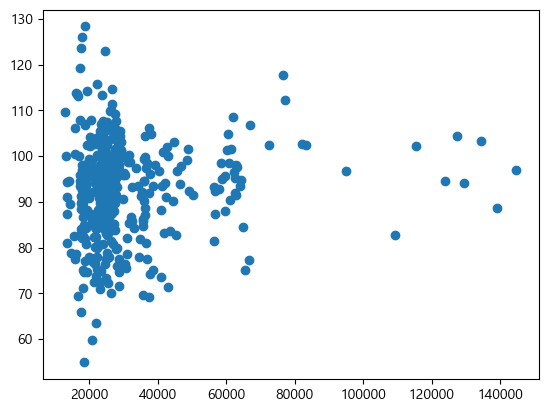

In [94]:
plt.scatter(data = data, x="avg_ticket", y="survival_rate_1y")

In [ ]:
data.corr(method="pearson") # 거의 상관 없음

,avg_ticket,survival_rate_1y
avg_ticket,1.000000,0.099797
survival_rate_1y,0.099797,1.000000


In [96]:
data.corr(method="spearman")

,avg_ticket,survival_rate_1y
avg_ticket,1.000000,0.105148
survival_rate_1y,0.105148,1.000000


In [97]:
data.corr(method="kendall")

,avg_ticket,survival_rate_1y
avg_ticket,1.000000,0.071721
survival_rate_1y,0.071721,1.000000


객단가와 신규점포 잔존율은 '거의 상관 없음'

- 귀무가설: 객단가와 신규점포 잔존율은 상관이 없다
- 대립가설: 객단가와 신규점포 잔존율는 양의 상관이 있다.

In [98]:
r, p_value = stats.pearsonr(data['avg_ticket'], data['survival_rate_1y'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.0998
p-value: 0.0461


In [99]:
r, p_value = stats.spearmanr(data['avg_ticket'], data['survival_rate_1y'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.1051
p-value: 0.0355


p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 객단가와 신규점포 잔존율 간에 통계적으로 유의한 양의 상관이 확인됐으나 상관의 크기가 매우 작아 객단가만으로 잔존율을 예측하기는 어렵다.

### 신규기업 수 & 폐업한 점포 수

In [100]:
data_corp = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"new_corp_cnt": "sum", "close_cnt": "sum"})

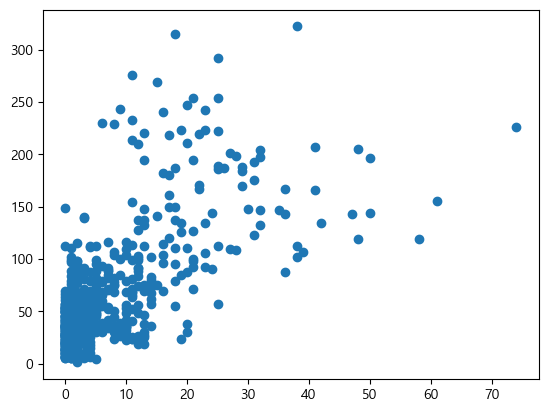

In [101]:
plt.scatter(data = data_corp, x="new_corp_cnt", y="close_cnt")

In [102]:
data_corp.corr(method="pearson")

,new_corp_cnt,close_cnt
new_corp_cnt,1.000000,0.667455
close_cnt,0.667455,1.000000


In [103]:
data_corp.corr(method="spearman")

,new_corp_cnt,close_cnt
new_corp_cnt,1.000000,0.613896
close_cnt,0.613896,1.000000


In [104]:
data_corp.corr(method="kendall")

,new_corp_cnt,close_cnt
new_corp_cnt,1.000000,0.455318
close_cnt,0.455318,1.000000


신규기업 수와 폐업한 점포 수는 '중간 정도 상관'

- 귀무가설: 신규 기업 수와 폐업 점포 수는 상관이 없다
- 대립가설: 신규 기업 수와 폐업 점포 수는 양의 상관이 있다.

In [105]:
r, p_value = stats.pearsonr(data_corp['new_corp_cnt'], data_corp['close_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.6675
p-value: 0.0000


In [106]:
r, p_value = stats.spearmanr(data_corp['new_corp_cnt'], data_corp['close_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.6139
p-value: 0.0000


p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 신규 기업 수가 늘어날 때 폐업 점포 수도 늘어난다.

### 신규기업 수 & 프랜차이즈 수

In [107]:
data_fran = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"new_corp_cnt": "sum", "franchise_cnt": "sum"})

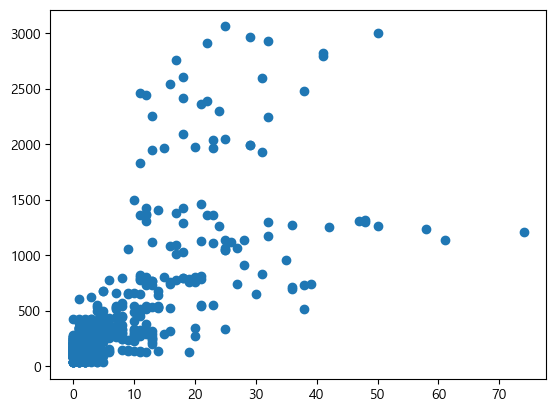

In [108]:
plt.scatter(data = data_fran, x="new_corp_cnt", y="franchise_cnt")

In [109]:
data_fran.corr(method="pearson")

,new_corp_cnt,franchise_cnt
new_corp_cnt,1.000000,0.705645
franchise_cnt,0.705645,1.000000


In [110]:
data_fran.corr(method="spearman")

,new_corp_cnt,franchise_cnt
new_corp_cnt,1.000000,0.729212
franchise_cnt,0.729212,1.000000


In [111]:
data_fran.corr(method="kendall")

,new_corp_cnt,franchise_cnt
new_corp_cnt,1.00000,0.55546
franchise_cnt,0.55546,1.00000


신규기업 수와 프랜차이즈 수는 '중간 정도 상관'

- 귀무가설: 신규 기업 수와 프랜차이즈 수는 상관이 없다
- 대립가설: 신규 기업 수와 프랜차이즈 수는 양의 상관이 있다.

In [113]:
r, p_value = stats.pearsonr(data_fran['new_corp_cnt'], data_fran['franchise_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.7056
p-value: 0.0000


In [ ]:
r, p_value = stats.spearmanr(data_fran['new_corp_cnt'], data_fran['franchise_cnt'])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.7292
p-value: 0.0000


p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 신규 기업 수가 늘어날 때 프랜차이즈 수도 늘어난다.

### 단순통과인구 & 유동인구/체류시간

external_inflow(외부유입 인구: 출발지_성남시 외 지역, 도착지: 성남시)<br>
단순통과인구 = duration <= 60(1시간) 

In [5]:
con = duckdb.connect()

path = file_path + '/t26_duration_raw_selected.parquet'

con.execute(f"""
select *
from read_parquet('{path}')
limit 1
""").fetchdf()

,source_row_id,etl_ymd,dow,d_time_cd,gu,adm_dong_nm,adm_dong_cd,duration,cnt
0,1,2023-01-30,월,11,성남시 분당구,정자1동,41135550,180.0,3.71


In [6]:
# 단순 통과인구 수
df_pass = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        sum(cnt) as pass_cnt
    from read_parquet('{path}')
    where duration <= 60
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [7]:
# 전체 유입인구 수
df_all = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        sum(cnt) as inflow_cnt
    from read_parquet('{path}')
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [8]:
# 분기별 행정동별 단순 통과인구 비율
pass_ratio = con.execute(f"""
    select 
        p.quarter,
        p.gu,
        p.adm_dong_nm,
        p.pass_cnt,
        a.inflow_cnt,
        (p.pass_cnt / nullif(a.inflow_cnt, 0)) * 100 as pass_ratio_pct
    from df_pass as p
    left join df_all as a
    on p.adm_dong_nm = a.adm_dong_nm
    and p.gu = a.gu
    and p.quarter = a.quarter
""").fetchdf()

In [9]:
pass_ratio.head(1)

,quarter,gu,adm_dong_nm,pass_cnt,inflow_cnt,pass_ratio_pct
0,2023Q1,성남시 중원구,성남동,1018145.15,5205980.33,19.557222


In [10]:
df.head(1)

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,close_cnt,open_rate,close_rate,franchise_ratio,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,77.0,1.687408,1.62413,4.893482,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624


In [11]:
duration = con.execute(f"""
    select 
        year(etl_ymd) || 'Q' || quarter(etl_ymd) as quarter,
        gu,
        adm_dong_nm,
        median(duration) as duration_m,
    from read_parquet('{path}')
    group by quarter, gu, adm_dong_nm
""").fetchdf()

In [13]:
duration.head(1)

,quarter,gu,adm_dong_nm,duration_m,q_idx
0,2023Q1,성남시 수정구,복정동,180.0,0


In [ ]:
# 전 기간 체류시간이 전반적으로 감소한 동 탐색
duration['q_idx'] = duration.groupby('adm_dong_nm').cumcount()  # 0,1,2,...

slopes = (duration.groupby('adm_dong_nm')
              .apply(lambda g: np.polyfit(g['q_idx'], g['duration_m'], 1)[0]))
# g['q_idx']: 분기를 0, 1, 2.. 등 숫자로 표현한 인덱스
# np.polyfit(X, Y, 1): 데이터 분포에서 가장 적합한 1차 직선을 그리는 함수
    # [0]은 그 직선의 기울기(slope) 값

dur_down_dongs = slopes[slopes < 0].index   # 기울기 음수 = 감소 추세

In [16]:
dur_down_dongs

Index(['고등동', '구미1동', '금광1동', '도촌동', '백현동', '분당동', '산성동', '상대원1동', '상대원3동',
       '서현2동', '성남동', '수내1동', '수내2동', '시흥동', '신촌동', '야탑2동', '야탑3동', '은행1동',
       '이매1동', '이매2동', '정자1동', '정자2동', '정자3동', '정자동', '태평1동'],
      dtype='str', name='adm_dong_nm')

In [ ]:
# 전 기간 유동인구가 전반적으로 증가한 동 탐색

# 1) 분기·동 단위로 floating_pop 집계
flow = (df.groupby(['base_quarter', 'adm_dong_nm'], as_index=False)['floating_pop']
          .sum())

# 2) 정렬 후 q_idx 부여
flow = flow.sort_values(['adm_dong_nm', 'base_quarter'])
flow['q_idx'] = flow.groupby('adm_dong_nm').cumcount()

# 3) 동별 회귀 기울기
slopes = (flow.groupby('adm_dong_nm')
              .apply(lambda g: np.polyfit(g['q_idx'], g['floating_pop'], 1)[0]))

flow_up_dongs = slopes[slopes > 0].index
flow_up_dongs


Index(['고등동', '구미1동', '구미동', '금곡동', '금광1동', '도촌동', '백현동', '복정동', '분당동', '산성동',
       '삼평동', '서현1동', '서현2동', '수내1동', '수내2동', '수내3동', '수진1동', '수진2동', '시흥동',
       '신촌동', '신흥2동', '신흥3동', '야탑1동', '야탑2동', '야탑3동', '양지동', '운중동', '위례동',
       '이매1동', '정자1동', '정자2동', '정자3동', '정자동', '중앙동', '태평1동', '판교동'],
      dtype='str', name='adm_dong_nm')

### 독립표본 t-검정

- 귀무가설: 유동인구가 증가하고 체류시간이 감소한 동의 단순 통과 인구 비율은 그렇지 않은 동의 단순 통과 인구 비율과 차이가 없다.
- 대립가설: 유동인구는 증가하고 체류시간이 감소한 동은 그렇지 않은 동보다 단순 통과 인구가 증가했을 것이다.

In [18]:
group_A = set(dur_down_dongs) & set(flow_up_dongs) # 체류시간 감소 + 유동인구 증가
group_B = set(slopes.index) - group_A  # 나머지

In [ ]:
from scipy import stats

# 1) 동별 평균 pass_ratio (분기 평균)
ratio_by_dong = pass_ratio.groupby('adm_dong_nm')['pass_ratio_pct'].mean()

# 2) 그룹별로 값 추출
A = ratio_by_dong[ratio_by_dong.index.isin(group_A)]
B = ratio_by_dong[ratio_by_dong.index.isin(group_B)]

# 3) Mann-Whitney U 검정 (단측: A > B)
u, p = stats.mannwhitneyu(A, B, alternative='greater')

print(f'A 동 수={len(A)}, B 동 수={len(B)}')
print(f'A 중앙값={A.median():.4f}, B 중앙값={B.median():.4f}')
print(f'U={u:.0f}, p-value={p:.4f}')

A 동 수=20, B 동 수=30
A 중앙값=17.9094, B 중앙값=16.8080
U=400, p-value=0.0244


### 유동인구 & 매출건수

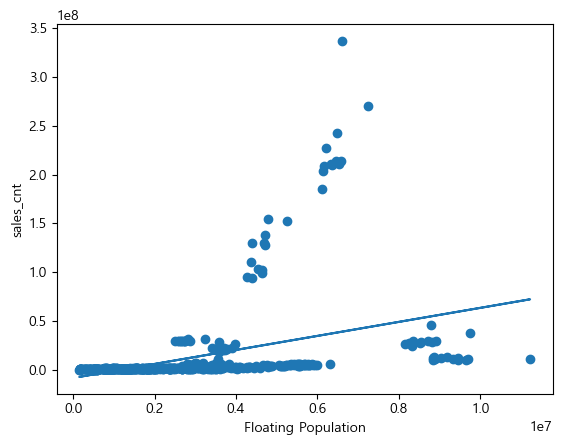

In [8]:
data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "sum", "sales_cnt": "sum"})

x = data["floating_pop"]
y = data["sales_cnt"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("sales_cnt")
plt.show()

In [9]:
r, p_value = stats.pearsonr(data["floating_pop"], data["sales_cnt"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.3987
p-value: 0.0000


In [11]:
r, p_value = stats.spearmanr(data["floating_pop"], data["sales_cnt"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.8333
p-value: 0.0000


### 유동인구 & 매출금액

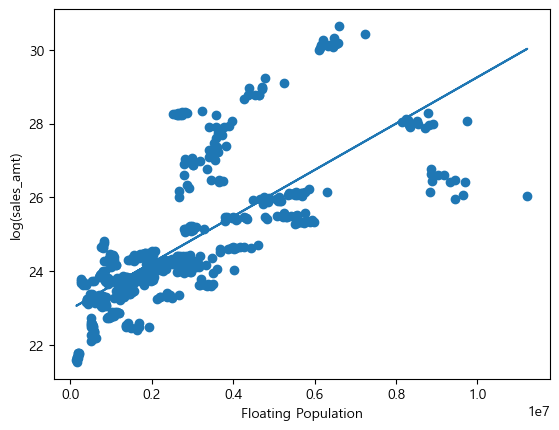

In [12]:
df["log_sales"] = np.log1p(df["sales_amt"])

data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "mean", "log_sales": "mean"})

x = data["floating_pop"]
y = data["log_sales"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("log(sales_amt)")
plt.show()

- 귀무가설: 유동인구와 매출금액은 상관이 없다
- 대립가설: 유동인구와 매출금액은 양의 상관이 있다.

In [13]:
r, p_value = stats.pearsonr(data["floating_pop"], data["log_sales"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.7291
p-value: 0.0000


In [15]:
r, p_value = stats.spearmanr(data["floating_pop"], data["log_sales"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.8006
p-value: 0.0000


유동인구와 매출금액은 강한 양의 관계

### 유동인구 & 객단가

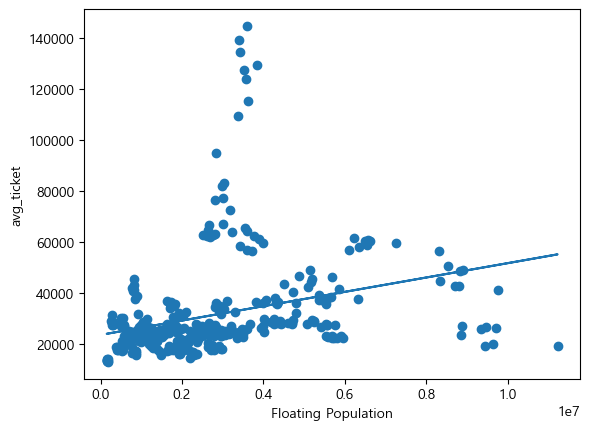

In [ ]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]
data = df_24_25.groupby(["base_quarter", "adm_dong_nm"]).agg({"floating_pop": "mean", "avg_ticket": "mean"})

plt.scatter(data = data, x="floating_pop", y="avg_ticket")

# x, y 값 추출
x = data["floating_pop"]
y = data["avg_ticket"]

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("Floating Population")
plt.ylabel("avg_ticket")
plt.show()

In [134]:
data.corr(method="pearson")

,avg_ticket,floating_pop
avg_ticket,1.000000,0.301855
floating_pop,0.301855,1.000000


In [135]:
data.corr(method="spearman")

,avg_ticket,floating_pop
avg_ticket,1.000000,0.472256
floating_pop,0.472256,1.000000


In [136]:
data.corr(method="kendall")

,avg_ticket,floating_pop
avg_ticket,1.000000,0.316667
floating_pop,0.316667,1.000000


유동인구와 객단가는 '약한 ~ 중간 정도 상관'

- 귀무가설: 유동인구와 객단가는 상관이 없다
- 대립가설: 유동인구와 객단가는 양의 상관이 있다.

In [138]:
r, p_value = stats.pearsonr(data["floating_pop"], data["avg_ticket"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.3019
p-value: 0.0000


In [139]:
r, p_value = stats.spearmanr(data["floating_pop"], data["avg_ticket"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

상관계수: 0.4723
p-value: 0.0000


p-value가 유의수준(0.05) 미만이므로 대립가설 채택 <br>
결론: 객단가와 객단가는 통계적으로 유의한 양의 상관관계가 있으나 상관 정도는 강하지 않다. 선형 관계가 약하고 비선형/단조 관계(값이 커질수록 같이 커지는 경향)가 보다 뚜렷하다.

In [22]:
df.head(1)

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,close_cnt,open_rate,close_rate,franchise_ratio,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,77.0,1.687408,1.62413,4.893482,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624


### 상관관계
(1) 공시지가 상승률 & 개폐업률 <br>
(2) 공시지가 상승률 & 상권활력도 <br>
(3) 상권활력도 & 거래량 증감률

In [72]:
df_land = pd.read_csv(file_path+'/법정동_분기_마스터.csv')

In [73]:
df['prefix'] = df['adm_dong_nm'].str.replace(r'\d*동$', '', regex=True)
df_land['prefix'] = df_land['legal_dong_nm'].str.replace(r'\d*동$', '', regex=True)

In [74]:
df_2425 = df.loc[df['year'].isin([2024, 2025])]
df_2425_land = df_land.loc[df_land['year'].isin([2024, 2025])]

In [75]:
df_2425.head(1)

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,open_rate,close_rate,franchise_ratio,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,prefix
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,1.198486,1.28259,5.277544,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624,신흥


In [76]:
df_2425_land.head(1)

,legal_dong_nm,legal_dong_full_nm,gu,base_quarter,year,quarter,land_price_median,land_price_growth,land_price_growth_yoy,land_parcel_cnt,land_parcel_count_ok,land_growth_23_25_median,land_growth_cagr_23_25_median,land_growth_23_25_mean,transaction_cnt,transaction_amt_sum,transaction_amt_mean,prefix
4,갈현동,경기도 성남시 중원구 갈현동,중원구,2024Q1,2024,1,1775000.0,0.860585,0.860585,19,False,4.532415,2.241095,5.474931,0,0.0,NaN,갈현


In [77]:
# 1. 전체 개폐업 점포 수
total_open_sum = df_2425['open_cnt'].sum()
total_close_sum = df_2425['close_cnt'].sum()

# 2. 동별(prefix) 개업 점포 수의 합계
df_open = df_2425.groupby(['prefix', 'year'])['open_cnt'].sum().reset_index()
df_close = df_2425.groupby(['prefix', 'year'])['close_cnt'].sum().reset_index()

# 3. 비중(Ratio)을 계산합니다. (동별 합계 / 전체 합계)
df_open['open_ratio'] = (df_open['open_cnt'] / total_open_sum) * 100
df_close['close_ratio'] = (df_close['close_cnt'] / total_close_sum) * 100

In [78]:
df_pct = df_open.merge(df_close, on=['prefix', 'year'], how='inner')

In [79]:
merge_land = df_2425_land[['prefix', 'year', 'land_price_growth']].merge(
    df_pct[['prefix', 'year', 'open_ratio', 'close_ratio']], 
    on=['prefix', 'year'], 
    how='inner'
)

In [83]:
merge_land = merge_land.drop_duplicates().reset_index(drop=True)
merge_land.head(8)

,prefix,year,land_price_growth,open_ratio,close_ratio
0,고등,2024,3.790412,0.719661,0.459513
1,고등,2025,2.858177,0.728619,0.559910
2,구미,2024,2.669029,2.236622,2.455883
3,구미,2025,3.018522,1.982800,2.336178
4,금곡,2024,4.493319,1.412446,1.552303
5,금곡,2025,3.022222,1.325848,1.490520
6,금광,2024,0.552373,2.203774,2.000232
7,금광,2025,2.669696,1.991758,2.069738


In [98]:
# 상권 활력도
merge_land['mkt_vital'] = merge_land['open_ratio'] - merge_land['close_ratio']

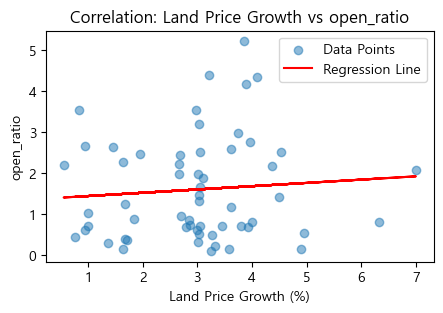

--- [ Analysis for open_ratio ] ---
Pearson  | 계수: 0.0838, p-value: 0.5315
Spearman | 계수: 0.0803, p-value: 0.5489




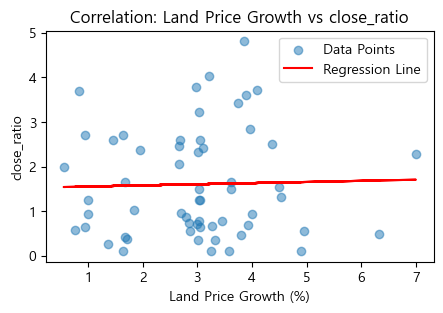

--- [ Analysis for close_ratio ] ---
Pearson  | 계수: 0.0278, p-value: 0.8359
Spearman | 계수: 0.0175, p-value: 0.8962




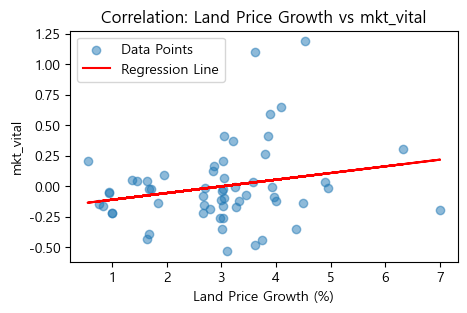

--- [ Analysis for mkt_vital ] ---
Pearson  | 계수: 0.2197, p-value: 0.0974
Spearman | 계수: 0.1979, p-value: 0.1365




In [100]:
# 분석할 대상 리스트
targets = ["open_ratio", "close_ratio", "mkt_vital"]

for target in targets:
    x = merge_land["land_price_growth"]
    y = merge_land[target]
    
    # 1. 시각화
    plt.figure(figsize=(5, 3))
    plt.scatter(x, y, alpha=0.5, label='Data Points')
    
    # 회귀선 계산 및 그리기
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color='red', label=f'Regression Line')
    
    plt.xlabel("Land Price Growth (%)")
    plt.ylabel(target)
    plt.title(f"Correlation: Land Price Growth vs {target}")
    plt.legend()
    plt.show()

    # 2. 통계 검정 (Pearson & Spearman)
    pearson_r, p_p = stats.pearsonr(x, y)
    spearman_r, p_s = stats.spearmanr(x, y)
    
    print(f"--- [ Analysis for {target} ] ---")
    print(f"Pearson  | 계수: {pearson_r:.4f}, p-value: {p_p:.4f}")
    print(f"Spearman | 계수: {spearman_r:.4f}, p-value: {p_s:.4f}")
    print("\n")

(4) 상권활력도 & 거래량 증감률

In [102]:
# 1. 전체 개폐업 점포 수
total_open_sum = df['open_cnt'].sum()
total_close_sum = df['close_cnt'].sum()

# 2. 동별(prefix) 개업 점포 수의 합계
df_open = df.groupby(['prefix', 'base_quarter'])['open_cnt'].sum().reset_index()
df_close = df.groupby(['prefix', 'base_quarter'])['close_cnt'].sum().reset_index()

# 3. 비중(Ratio)을 계산합니다. (동별 합계 / 전체 합계)
df_open['open_ratio'] = (df_open['open_cnt'] / total_open_sum) * 100
df_close['close_ratio'] = (df_close['close_cnt'] / total_close_sum) * 100

df_pct = df_open.merge(df_close, on=['prefix', 'base_quarter'], how='inner')

In [133]:
df_pct['mkt_vital'] = df_pct['open_ratio'] - df_pct['close_ratio']

In [136]:
df_land.columns

Index(['legal_dong_nm', 'legal_dong_full_nm', 'gu', 'base_quarter', 'year',
       'quarter', 'land_price_median', 'land_price_growth',
       'land_price_growth_yoy', 'land_parcel_cnt', 'land_parcel_count_ok',
       'land_growth_23_25_median', 'land_growth_cagr_23_25_median',
       'land_growth_23_25_mean', 'transaction_cnt', 'transaction_amt_sum',
       'transaction_amt_mean', 'prefix'],
      dtype='str')

In [139]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# 1. 동별·분기별 거래량 합계
df_land_qtr = (
    df_land.groupby(['prefix', 'base_quarter'])['transaction_cnt']
           .sum()
           .reset_index()
           .sort_values(['prefix', 'base_quarter'])
)

# 2. 전 분기 대비 거래량 증감률(%)
df_land_qtr['trans_growth'] = (
    df_land_qtr.groupby('prefix')['transaction_cnt'].pct_change() * 100
)

# 3. 상권 활력도와 병합 후 inf / NaN 제거
df_corr = (
    df_pct.merge(
        df_land_qtr[['prefix', 'base_quarter', 'trans_growth']],
        on=['prefix', 'base_quarter'], how='inner'
    )
    .replace([np.inf, -np.inf], np.nan)          # 0 → 양수일 때 생기는 inf 처리
    .dropna(subset=['mkt_vital', 'trans_growth'])
)

# (선택) 분산이 0이면 상관계수 정의 불가 → 점검
print("샘플 수:", len(df_corr))
print("mkt_vital std:", df_corr['mkt_vital'].std())
print("trans_growth std:", df_corr['trans_growth'].std())

# 4. 상관계수
pearson_r,  pearson_p  = pearsonr(df_corr['mkt_vital'],  df_corr['trans_growth'])
spearman_r, spearman_p = spearmanr(df_corr['mkt_vital'], df_corr['trans_growth'])

print(f"피어슨 상관계수 : {pearson_r:.4f} (p-value: {pearson_p:.4g})")
print(f"스피어만 상관계수: {spearman_r:.4f} (p-value: {spearman_p:.4g})")

샘플 수: 249
mkt_vital std: 0.10881490376327008
trans_growth std: 213.6992197227982
피어슨 상관계수 : 0.0819 (p-value: 0.198)
스피어만 상관계수: -0.0187 (p-value: 0.769)


(5) 유동인구 & 소득수준

In [128]:
data = df[["base_quarter", "adm_dong_nm", 'floating_pop', '전입_소득수준_가중평균_분기']]


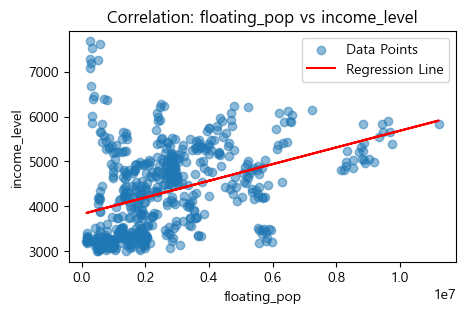

--- [ Analysis for mkt_vital ] ---
Pearson  | 계수: 0.3885, p-value: 0.0000
Spearman | 계수: 0.4699, p-value: 0.0000




In [129]:
x = data['floating_pop']
y = data['전입_소득수준_가중평균_분기']

# 1. 시각화
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha=0.5, label='Data Points')

# 회귀선 계산 및 그리기
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, color='red', label=f'Regression Line')

plt.xlabel("floating_pop")
plt.ylabel("income_level")
plt.title("Correlation: floating_pop vs income_level")
plt.legend()
plt.show()

# 2. 통계 검정 (Pearson & Spearman)
pearson_r, p_p = stats.pearsonr(x, y)
spearman_r, p_s = stats.spearmanr(x, y)

print(f"--- [ Analysis for {target} ] ---")
print(f"Pearson  | 계수: {pearson_r:.4f}, p-value: {p_p:.4f}")
print(f"Spearman | 계수: {spearman_r:.4f}, p-value: {p_s:.4f}")
print("\n")

### 프랜차이즈 침투율 & 업종 다양성

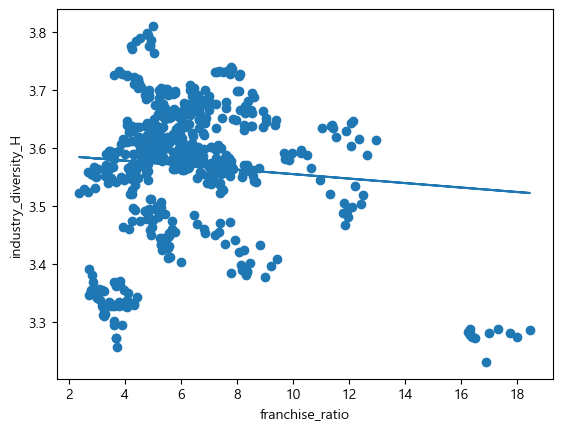

상관계수: -0.0854
p-value: 0.0366
상관계수: 0.1465
p-value: 0.0003


In [53]:
data = df.groupby(["base_quarter", "adm_dong_nm"]).agg({"franchise_ratio": "mean", "industry_diversity_H": "mean"})

x = data["franchise_ratio"]
y = data["industry_diversity_H"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("franchise_ratio")
plt.ylabel("industry_diversity_H")
plt.show()

r, p_value = stats.pearsonr(data["franchise_ratio"], data["industry_diversity_H"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

r, p_value = stats.spearmanr(data["franchise_ratio"], data["industry_diversity_H"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

### 프랜차이즈 침투율 & 신생 점포 잔존율

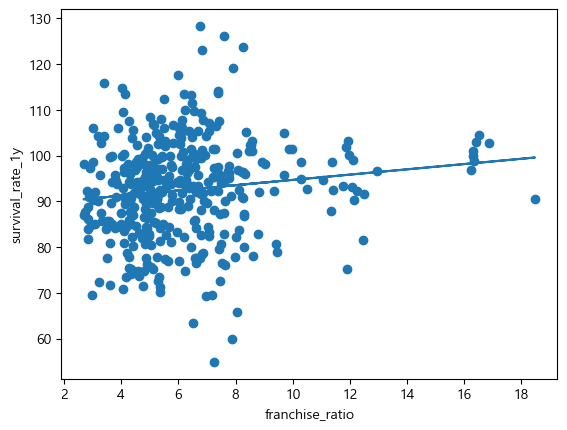

상관계수: 0.1333
p-value: 0.0076
상관계수: 0.1596
p-value: 0.0014


In [55]:
df_24_25 = df.loc[df['year'].isin([2024, 2025])]

data = df_24_25.groupby(["base_quarter", "adm_dong_nm"]).agg({"franchise_ratio": "mean", "survival_rate_1y": "mean"})

x = data["franchise_ratio"]
y = data["survival_rate_1y"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("franchise_ratio")
plt.ylabel("survival_rate_1y")
plt.show()

r, p_value = stats.pearsonr(data["franchise_ratio"], data["survival_rate_1y"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

r, p_value = stats.spearmanr(data["franchise_ratio"], data["survival_rate_1y"])
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

### 체류시간 & 객단가

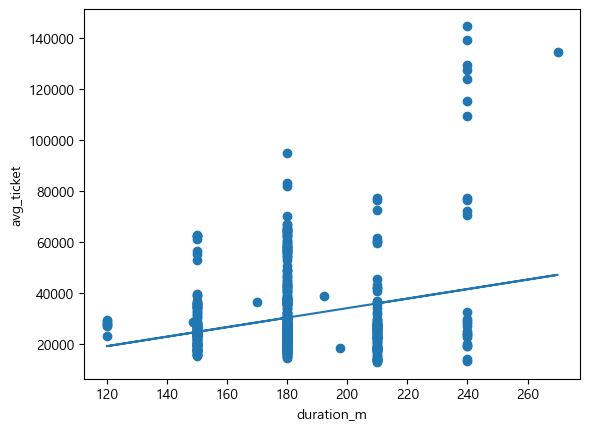

상관계수: 0.2469
p-value: 0.0000
상관계수: 0.0357
p-value: 0.3829


In [57]:
# (분기, 동) 단위로 매칭
df_ticket = (df.groupby(['base_quarter', 'adm_dong_nm'], as_index=False)['avg_ticket']
               .mean())

merged = duration.merge(
    df_ticket,
    left_on=['quarter', 'adm_dong_nm'],
    right_on=['base_quarter', 'adm_dong_nm'],
    how='inner'
).dropna(subset=['duration_m', 'avg_ticket'])

x = merged["duration_m"]
y = merged["avg_ticket"]

plt.scatter(x, y)

# 회귀선 계산
m, b = np.polyfit(x, y, 1)

# 회귀선 그리기
plt.plot(x, m * x + b)

plt.xlabel("duration_m")
plt.ylabel("avg_ticket")
plt.show()

r, p_value = stats.pearsonr(x, y)
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')

r, p_value = stats.spearmanr(x, y)
print(f'상관계수: {r:.4f}')
print(f'p-value: {p_value:.4f}')